In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd
import numpy as np
from datetime import datetime
import re
import warnings
from pathlib import Path
warnings.filterwarnings('ignore', category=UserWarning, message='Parsing.*in DD/MM/YYYY format')
# warnings.filterwarnings('ignore')  # Suppress all warnings

In [31]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None) # Show full column content

In [32]:
from pathlib import Path
ROOT = Path.cwd().parent 
RAW_PATH = ROOT / "data" / "cleaned_EMI_dataset.csv"
REPORTS_DIR = ROOT / "data" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

### LOAD CLEAN DATA

In [33]:
print(f"📥 Loading dataset: {RAW_PATH}")
df = pd.read_csv(RAW_PATH)
print(f"Initial shape: {df.shape}")

📥 Loading dataset: c:\Users\malay chand\Desktop\project\guvi_project\emi\EMIPredict_AI\data\cleaned_EMI_dataset.csv
Initial shape: (404800, 27)


### EMI Eligibility Distribution

C:\Users\malay chand\AppData\Local\Temp\ipykernel_23696\825744417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emi_eligibility', palette='Set2')


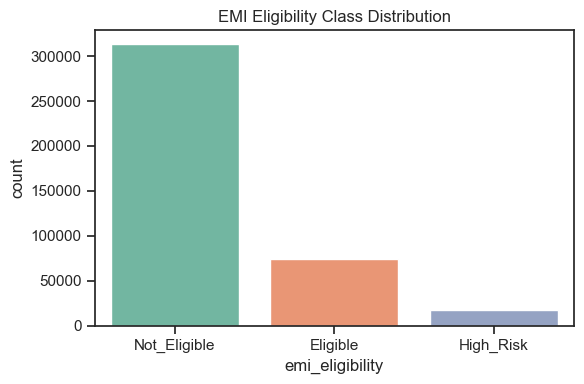

✅ EMI eligibility distribution saved.


In [34]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='emi_eligibility', palette='Set2')
plt.title("EMI Eligibility Class Distribution")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "emi_eligibility_distribution.png")
plt.show() 
plt.close()
print("✅ EMI eligibility distribution saved.")

### Histograms of Numeric Features

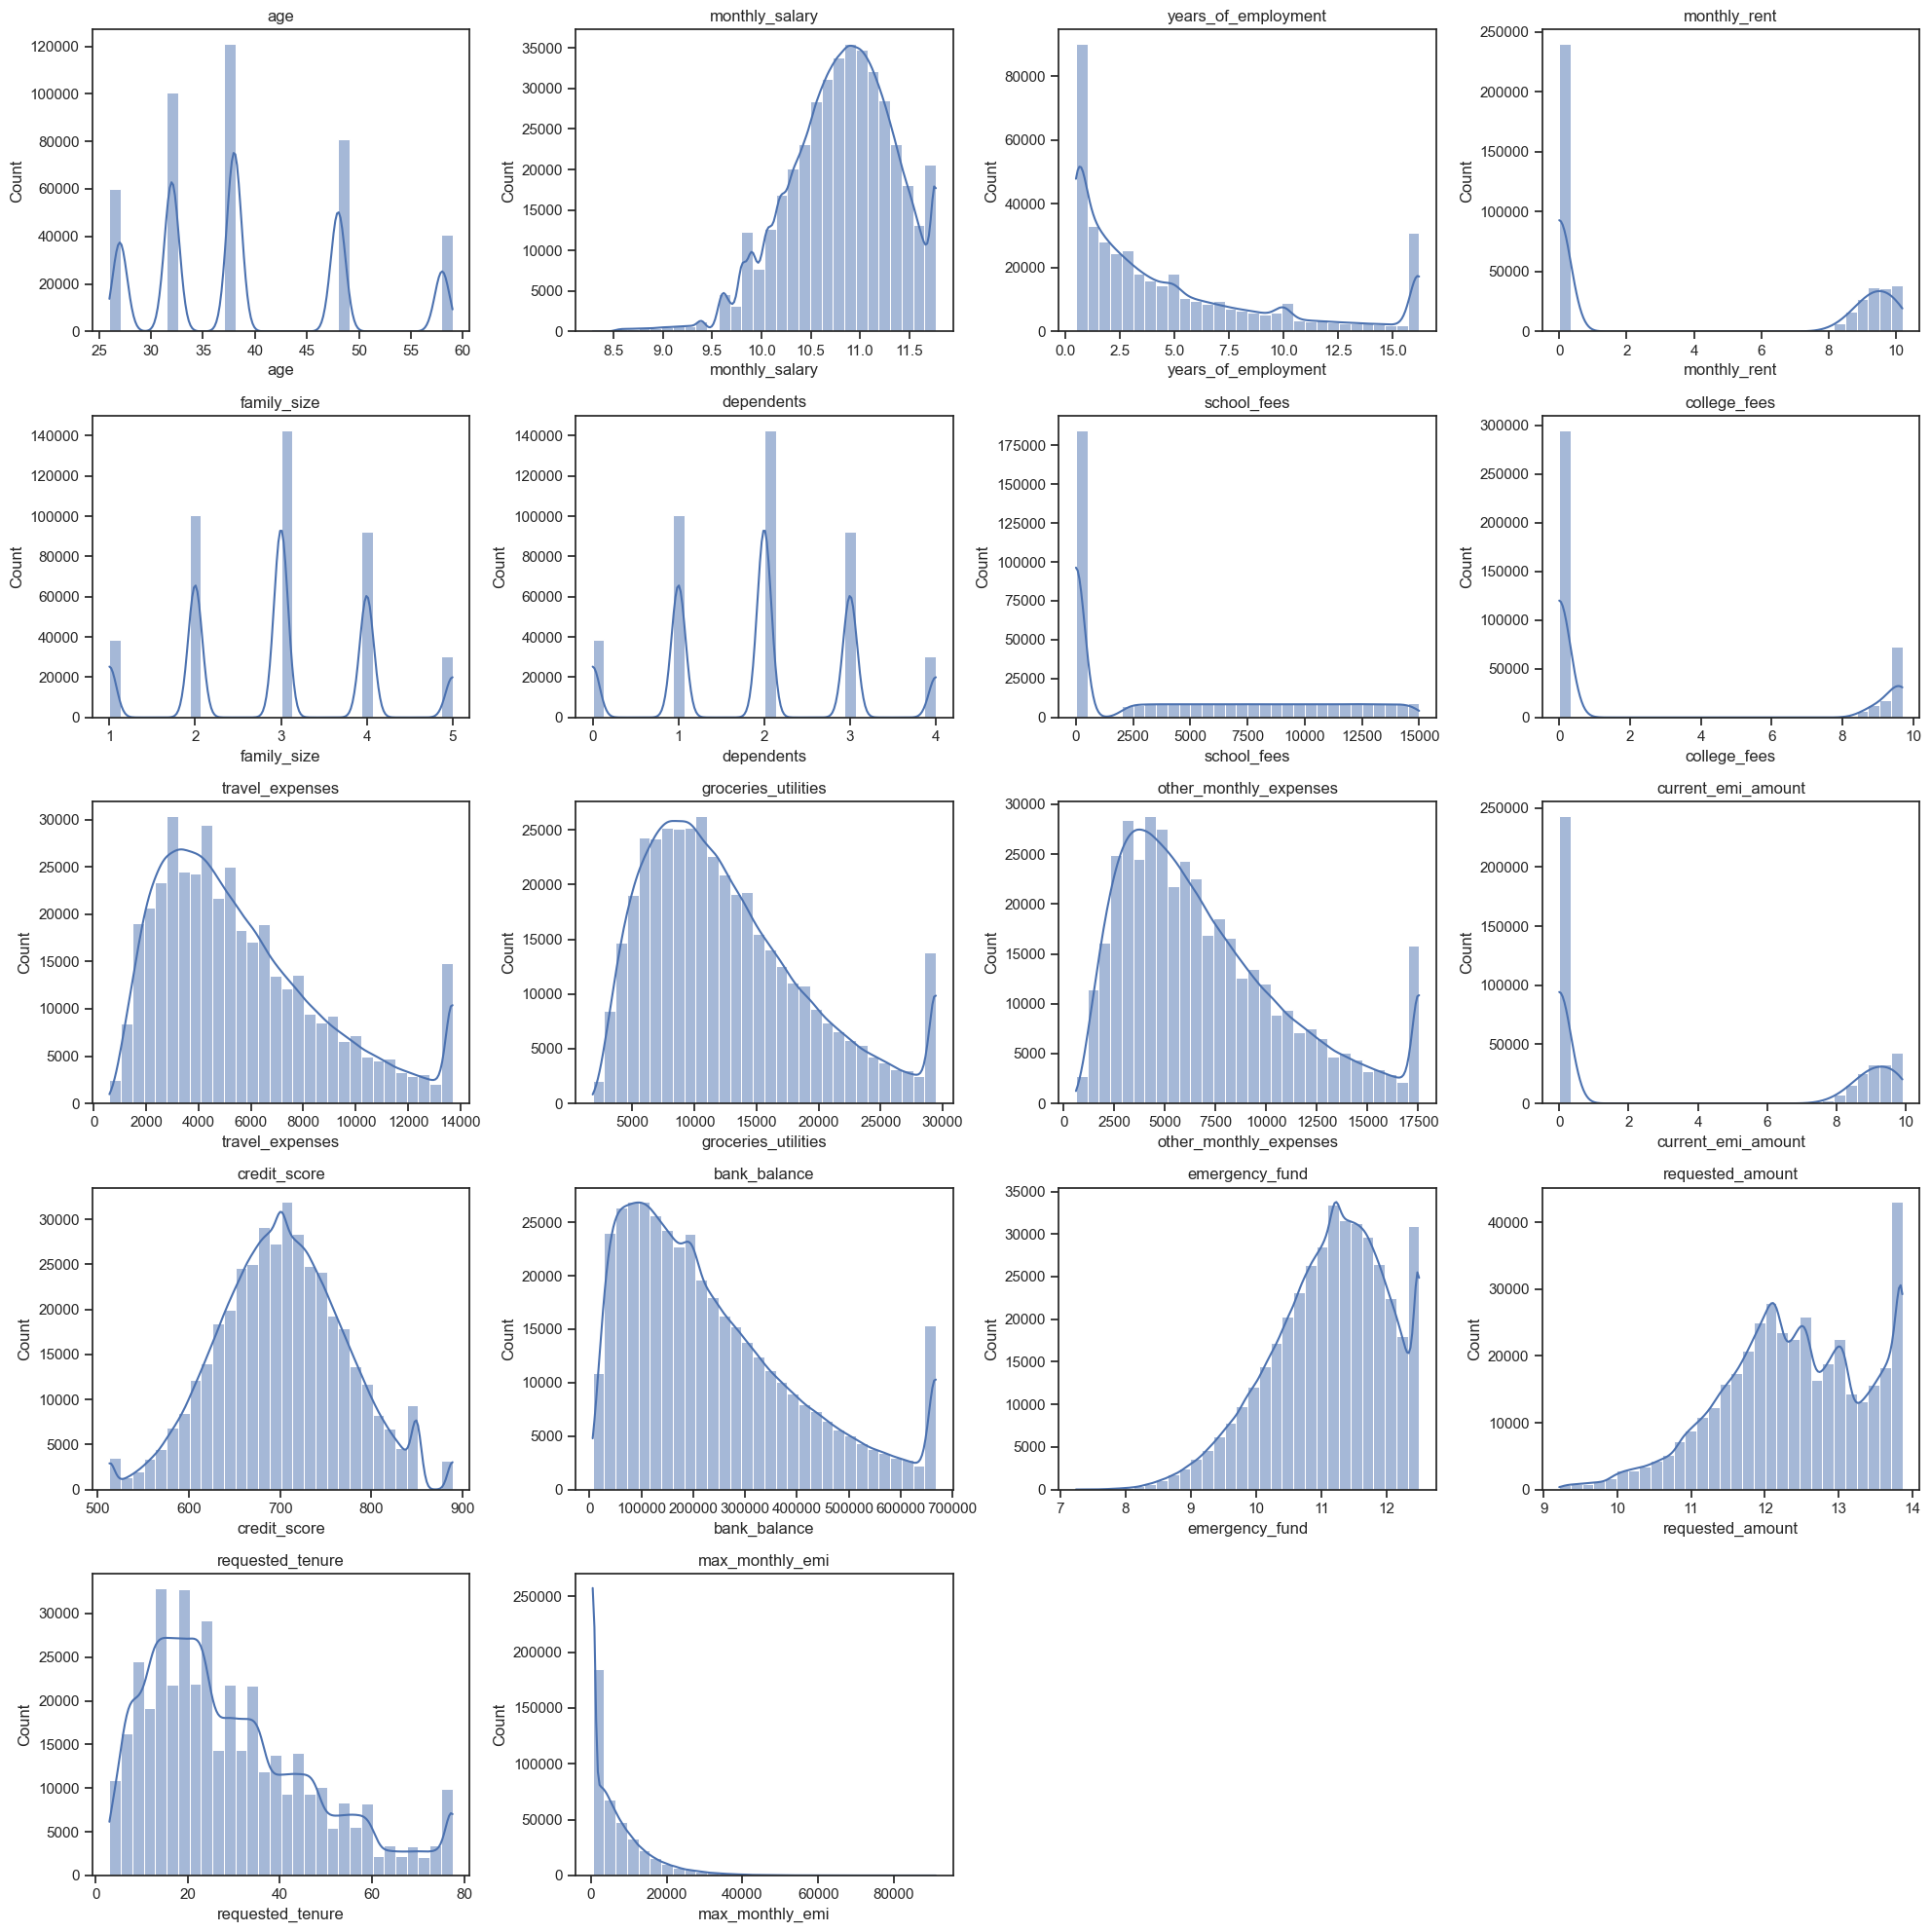

✅ Numeric feature histograms saved.


In [35]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(5*n_cols, 4*n_rows))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "numeric_features_histograms.png")
plt.show()
plt.close()
print("✅ Numeric feature histograms saved.")

### Correlation Heatmap

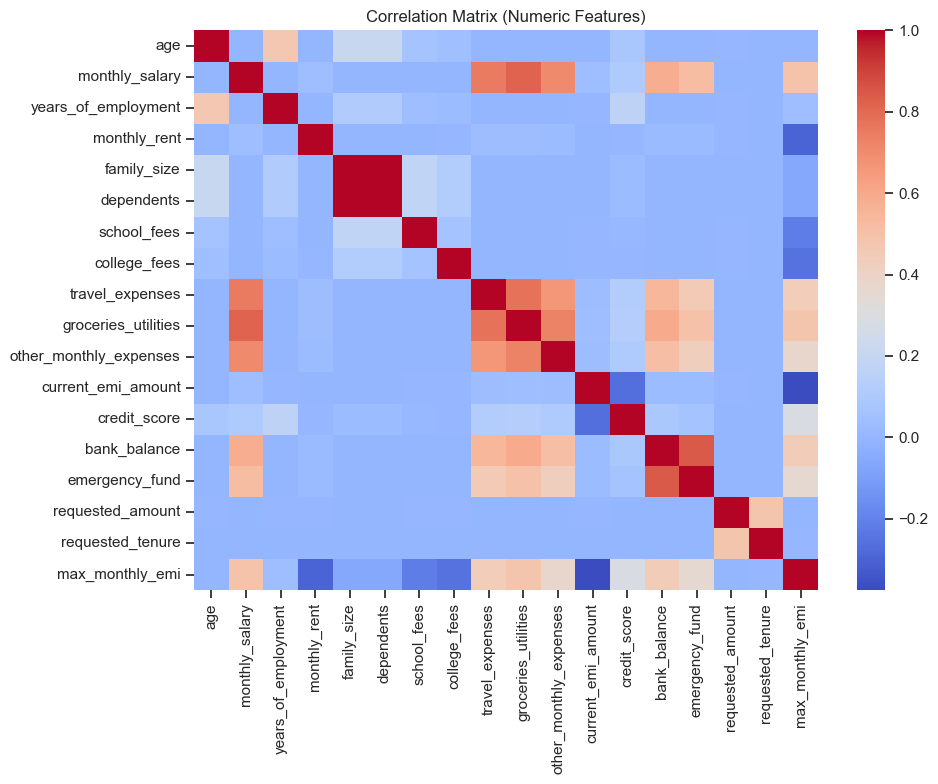

✅ Correlation matrix saved.


In [36]:
plt.figure(figsize=(10,8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_matrix.png")
plt.show()
plt.close()
print("✅ Correlation matrix saved.")

###  Debt-to-Income Ratio Distribution

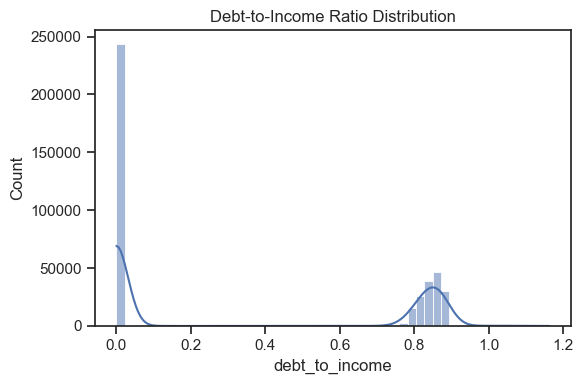

✅ Debt-to-Income ratio distribution saved.


In [37]:
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary'].replace(0, np.nan)
plt.figure(figsize=(6,4))
sns.histplot(df['debt_to_income'].dropna(), kde=True)
plt.title("Debt-to-Income Ratio Distribution")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "debt_to_income_distribution.png")
plt.show()
plt.close()
print("✅ Debt-to-Income ratio distribution saved.")

### Expense-to-Income Ratio Distribution

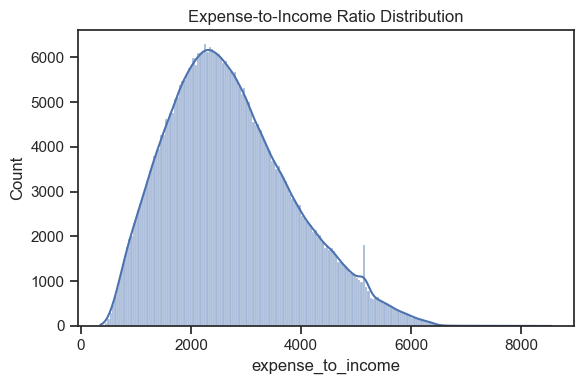

✅ Expense-to-Income ratio distribution saved.


In [38]:
expense_cols = [
    'school_fees','college_fees','travel_expenses',
    'groceries_utilities','other_monthly_expenses','monthly_rent'
]
df['total_monthly_expenses'] = df[expense_cols].sum(axis=1)
df['expense_to_income'] = df['total_monthly_expenses'] / df['monthly_salary'].replace(0, np.nan)

plt.figure(figsize=(6,4))
sns.histplot(df['expense_to_income'].dropna(), kde=True)
plt.title("Expense-to-Income Ratio Distribution")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "expense_to_income_distribution.png")
plt.show()
plt.close()
print("✅ Expense-to-Income ratio distribution saved.")

### Affordability Ratio Distribution

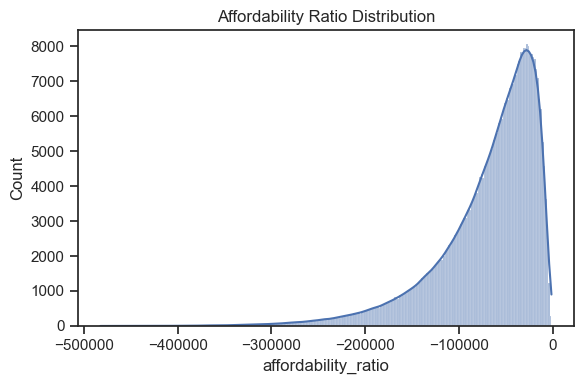

✅ Affordability ratio distribution saved.


In [39]:
df['monthly_disposable'] = df['monthly_salary'] - df['total_monthly_expenses'] - df['current_emi_amount']
df['instalment_if_approved'] = df['requested_amount'] / df['requested_tenure'].replace(0, np.nan)
df['affordability_ratio'] = df['monthly_disposable'] / df['instalment_if_approved'].replace(0, np.nan)

plt.figure(figsize=(6,4))
sns.histplot(df['affordability_ratio'].dropna(), kde=True)
plt.title("Affordability Ratio Distribution")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "affordability_ratio_distribution.png")
plt.show()
plt.close()
print("✅ Affordability ratio distribution saved.")


### Correlation with Target

C:\Users\malay chand\AppData\Local\Temp\ipykernel_23696\737789191.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.index, y=corr_target.values, palette='viridis')


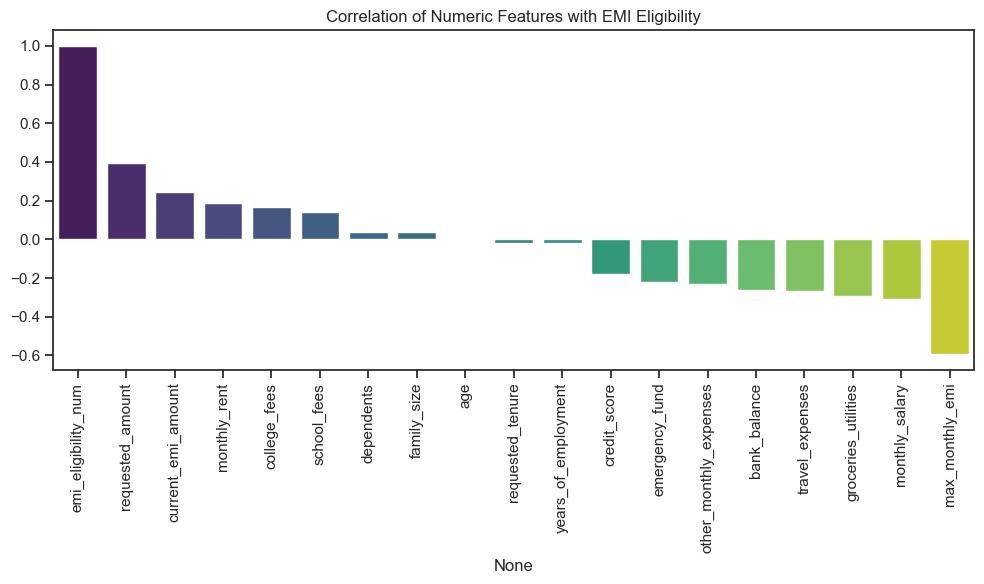

✅ Feature-target correlation saved.


In [40]:
le = LabelEncoder()
df['emi_eligibility_num'] = le.fit_transform(df['emi_eligibility'])
plt.figure(figsize=(10,6))
corr_target = df[num_cols + ['emi_eligibility_num']].corr()['emi_eligibility_num'].sort_values(ascending=False)
sns.barplot(x=corr_target.index, y=corr_target.values, palette='viridis')
plt.xticks(rotation=90)
plt.title("Correlation of Numeric Features with EMI Eligibility")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_target_correlation.png")
plt.show()
plt.close()
print("✅ Feature-target correlation saved.")

### Pairplot of Key Features

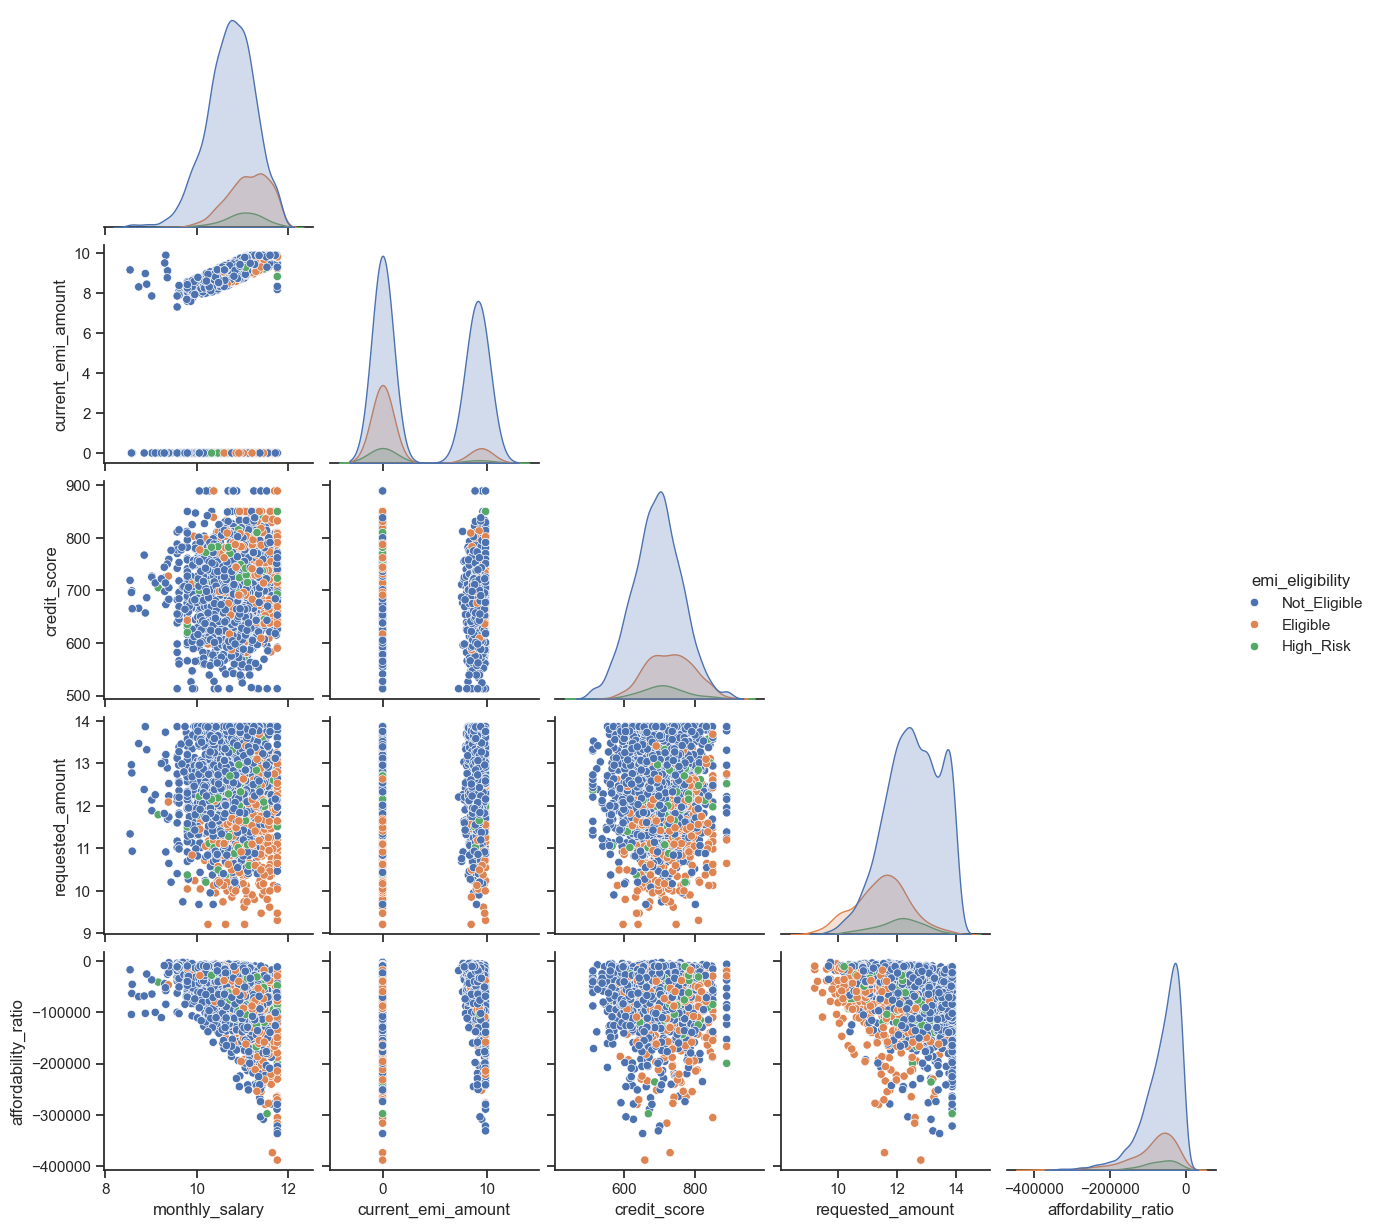

✅ Pairplot of key features (2000 samples) saved.


In [41]:
key_features = [
    'monthly_salary', 'current_emi_amount', 'credit_score', 
    'requested_amount', 'affordability_ratio', 'emi_eligibility'
]

# Take random sample of 2000 points (or all if fewer than 2000)
SAMPLE_SIZE = min(2000, len(df))
df_sample = df[key_features].sample(n=SAMPLE_SIZE, random_state=42)

sns.set(style="ticks")
pairplot_fig = sns.pairplot(
    df_sample, 
    hue='emi_eligibility', 
    corner=True, 
    diag_kind='kde', 
   
)
pairplot_fig.savefig(REPORTS_DIR / "pairplot_key_features.png")
plt.show()
plt.close()
print("✅ Pairplot of key features (2000 samples) saved.")

### Scatterplots of Key Features vs Ratios

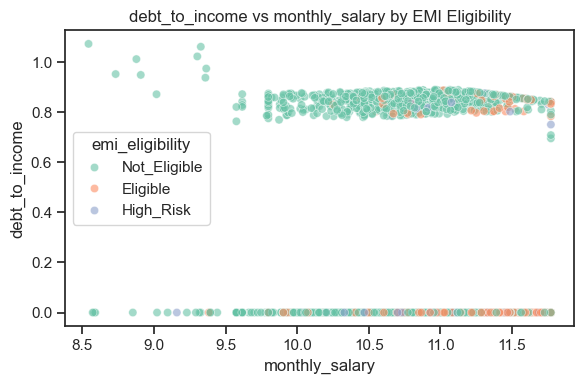

✅ Saved scatter plot: debt_to_income_vs_monthly_salary_scatter.png


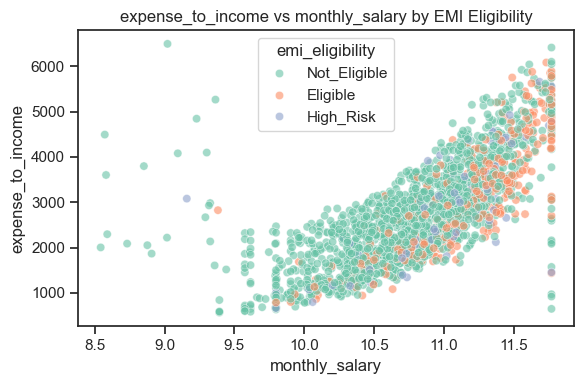

✅ Saved scatter plot: expense_to_income_vs_monthly_salary_scatter.png


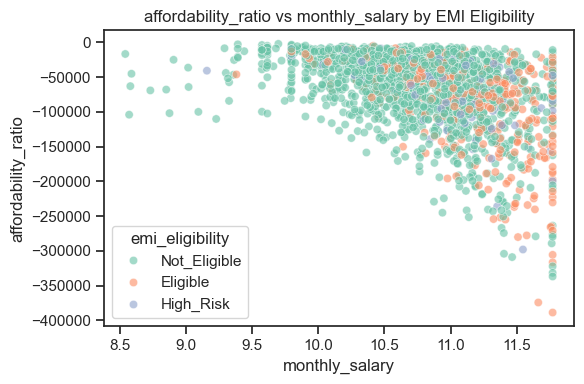

✅ Saved scatter plot: affordability_ratio_vs_monthly_salary_scatter.png


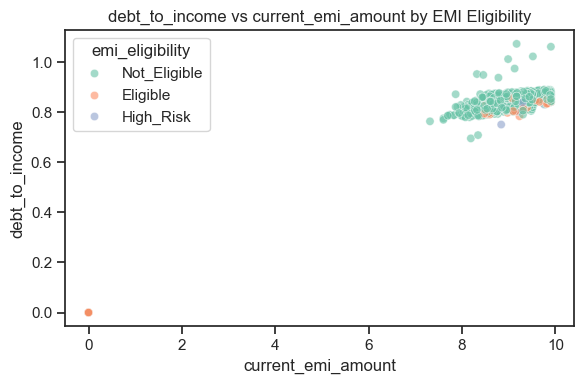

✅ Saved scatter plot: debt_to_income_vs_current_emi_amount_scatter.png


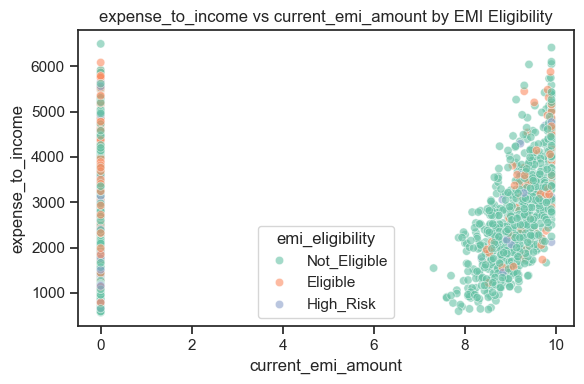

✅ Saved scatter plot: expense_to_income_vs_current_emi_amount_scatter.png


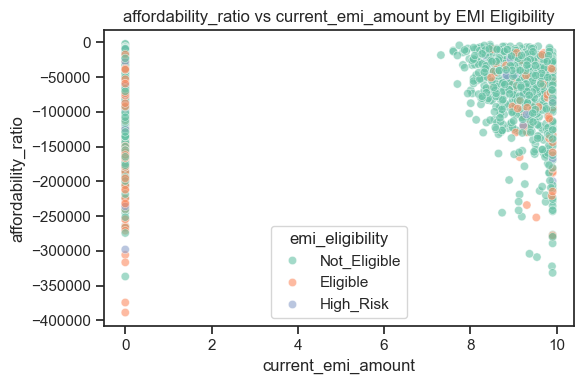

✅ Saved scatter plot: affordability_ratio_vs_current_emi_amount_scatter.png


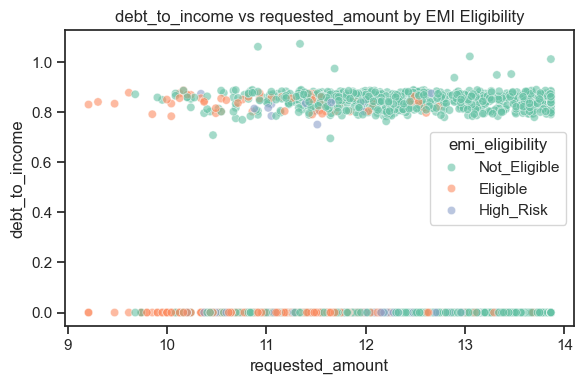

✅ Saved scatter plot: debt_to_income_vs_requested_amount_scatter.png


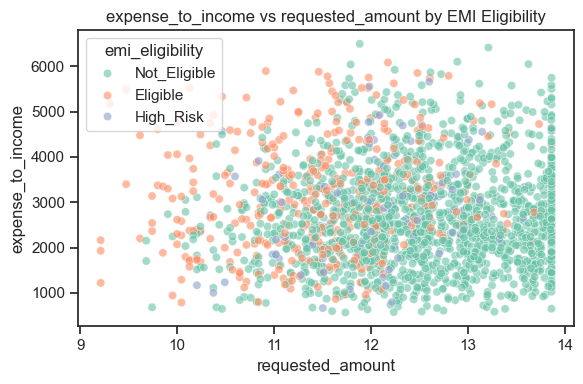

✅ Saved scatter plot: expense_to_income_vs_requested_amount_scatter.png


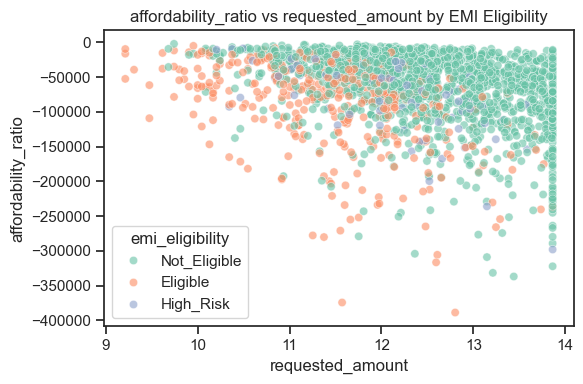

✅ Saved scatter plot: affordability_ratio_vs_requested_amount_scatter.png


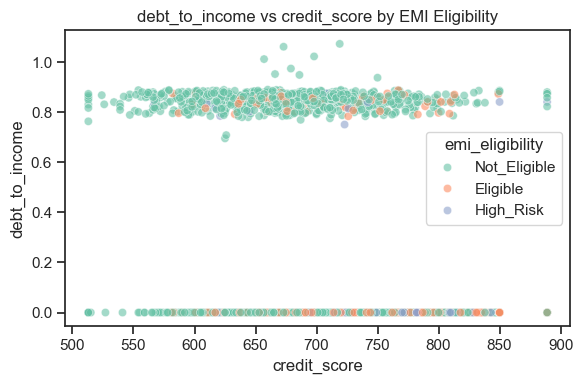

✅ Saved scatter plot: debt_to_income_vs_credit_score_scatter.png


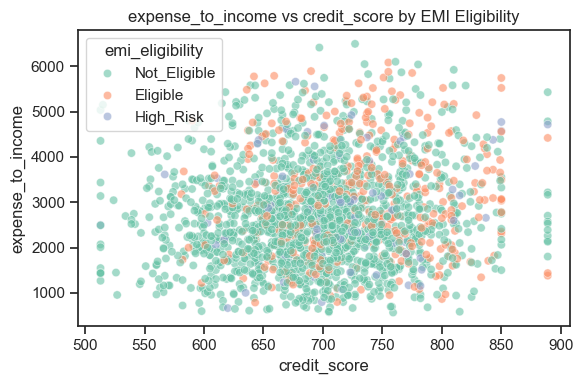

✅ Saved scatter plot: expense_to_income_vs_credit_score_scatter.png


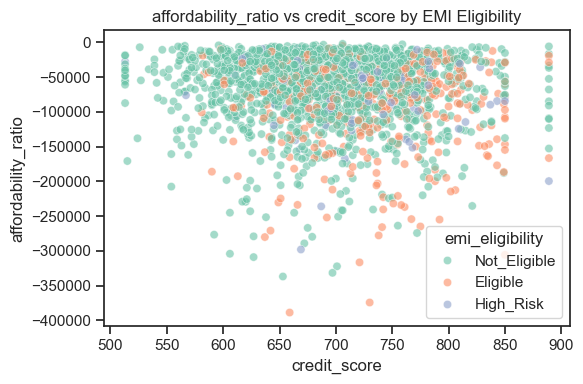

✅ Saved scatter plot: affordability_ratio_vs_credit_score_scatter.png

🎯 All plots generated and saved to: C:\Users\malay chand\Desktop\project\guvi_project\emi\EMIPredict_AI\data\reports


In [42]:
scatter_features = ['monthly_salary', 'current_emi_amount', 'requested_amount', 'credit_score']
ratio_features = ['debt_to_income', 'expense_to_income', 'affordability_ratio']

for feat in scatter_features:
    for ratio in ratio_features:
        plt.figure(figsize=(6,4))
        sns.scatterplot(
            data=df.sample(n=SAMPLE_SIZE, random_state=42),
            x=feat,
            y=ratio,
            hue='emi_eligibility',
            alpha=0.6,
            palette='Set2'
        )
        plt.title(f"{ratio} vs {feat} by EMI Eligibility")
        plt.tight_layout()
        filename = REPORTS_DIR / f"{ratio}_vs_{feat}_scatter.png"
        plt.savefig(filename)
        plt.show()
        plt.close()
        print(f"✅ Saved scatter plot: {filename.name}")

print(f"\n🎯 All plots generated and saved to: {REPORTS_DIR.resolve()}")